In [2]:
#importing the necessary libraries from the file ...
from imports import *
from datasets import *

import joblib

#plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

In [3]:
# load the dataset ...
# online_gambling is the path to the dataset defined in datasets.py
df = pd.read_csv(online_gambling)
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
# checking the structure of the dataset ...
# also converting the columns and displaying information ...
print(df.shape)
print('\n columns in the dataset: \n', df.columns.tolist())

(40034, 13)

 columns in the dataset: 
 ['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [6]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


In [7]:
df.describe(include=[object]).T

,count,unique,top,freq
Gender,40034,2,Male,23959
Location,40034,4,USA,16000
GameGenre,40034,5,Sports,8048
GameDifficulty,40034,3,Easy,20015
EngagementLevel,40034,3,Medium,19374


In [8]:
# Checking the Missing values in the dataset ...
missing = df.isnull().sum().sort_values(ascending=False)
print('Missing values in the dataset: \n', missing[missing > 0])
# Duplicate values in the dataset ...
duplicate = df.duplicated().sum()
print('Duplicate values in the dataset: \n', duplicate)

Missing values in the dataset: 
 Series([], dtype: int64)
Duplicate values in the dataset: 
 0


Target distribution: 
 EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


<Axes: xlabel='EngagementLevel'>

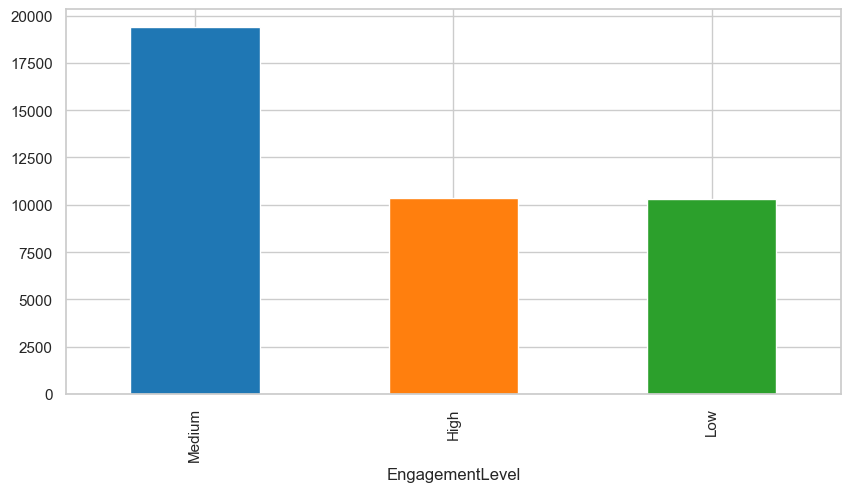

In [9]:
# target distribution
target=df['EngagementLevel'].value_counts()
print('Target distribution: \n', target)
target.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])

#### Exploratory Data Analysis (EDA) ...
##### we are doing :
* 1. Univariate Analysis: Distribution of each feature and its relationship
    with the target variable.
* 2. Bivariate Analysis: Relationship between two features and their relationship with the target variable.
* 3. Multivariate Analysis: Relationship between multiple features and their relationship with the target variable.

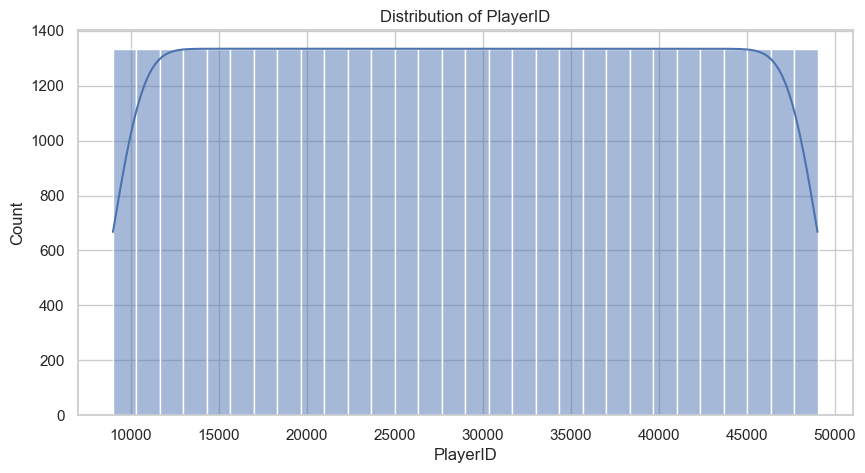

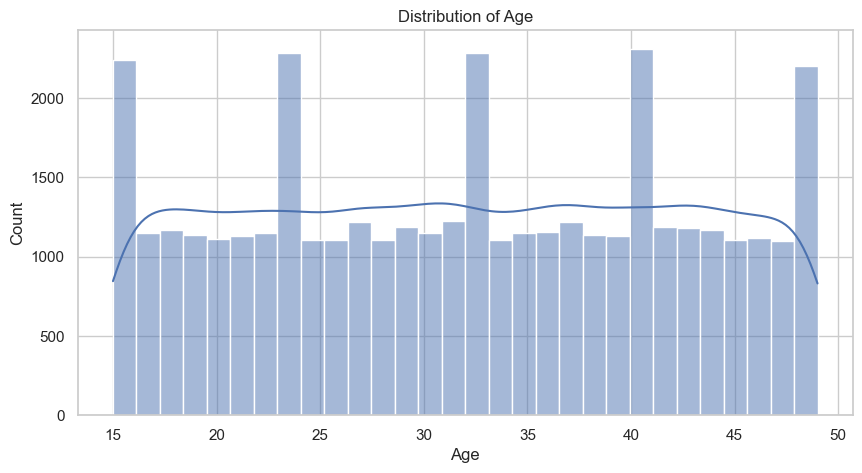

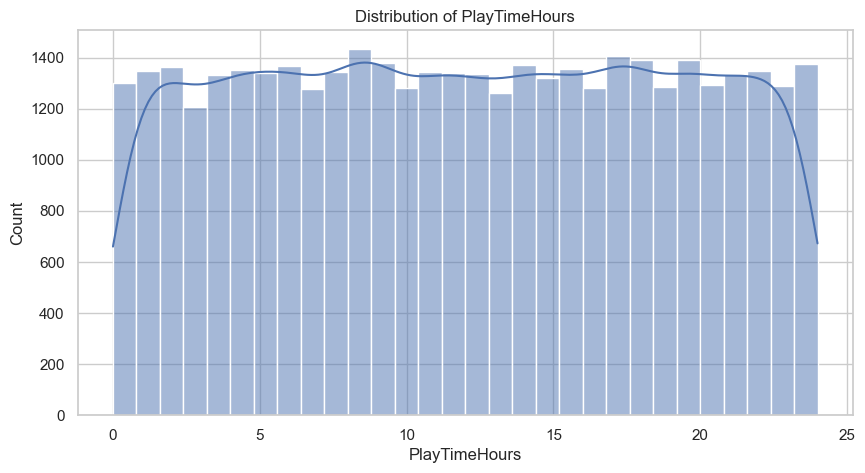

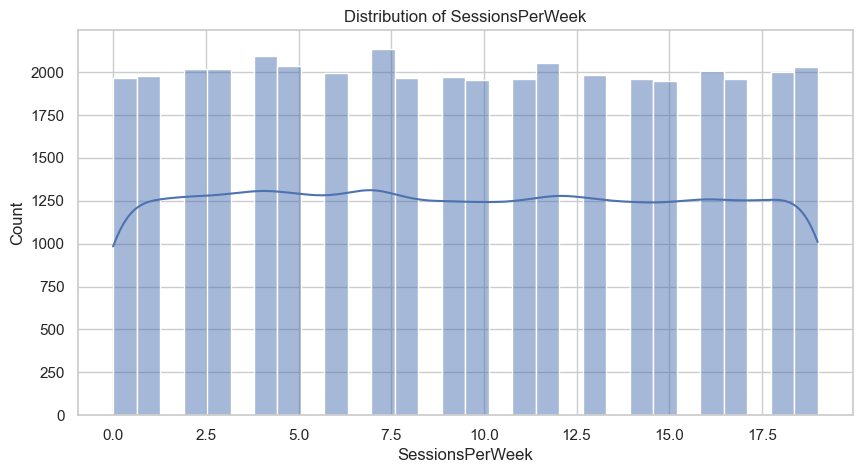

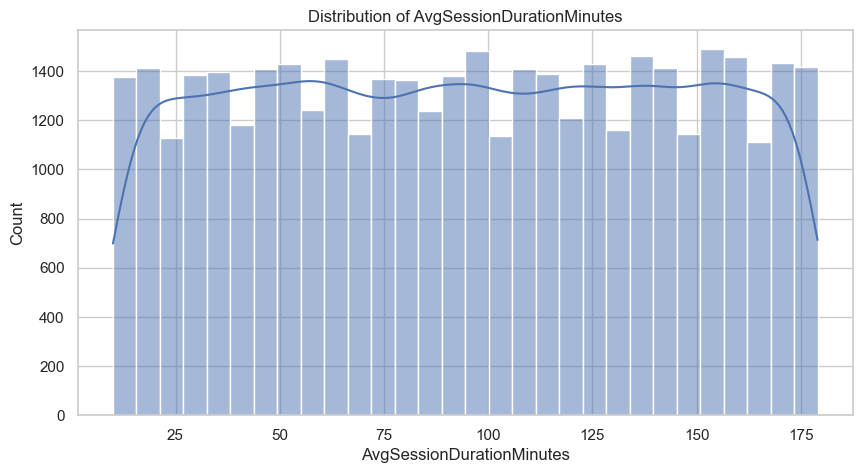

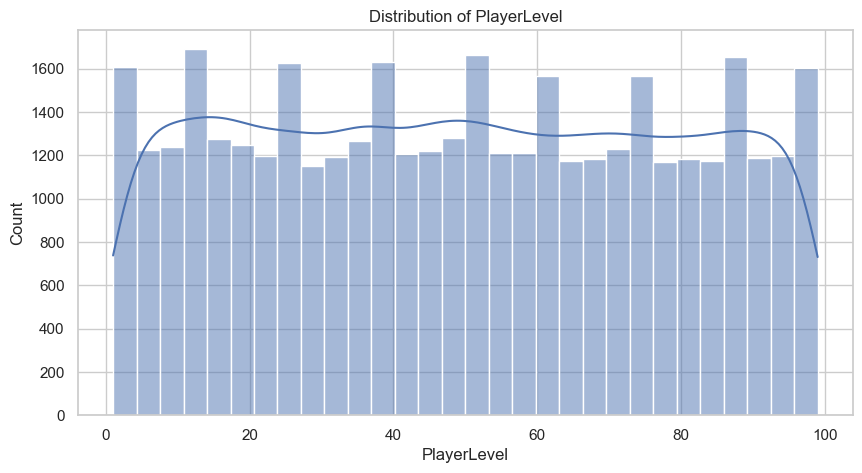

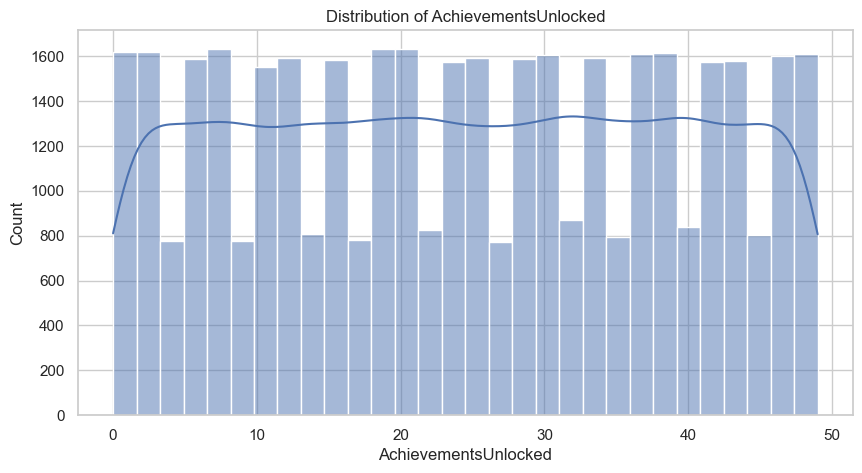

In [10]:
# univariate analysis(Numerical features) ...
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('InGamePurchases')  # remove the UserID column as it is not a numeric feature
for col in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
   # plt.xlabel(col)
    #plt.ylabel('Count')
    plt.show()

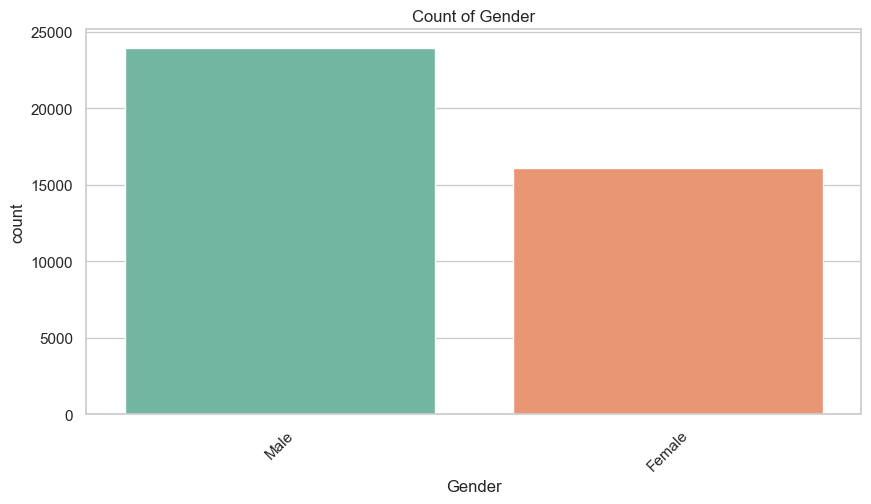

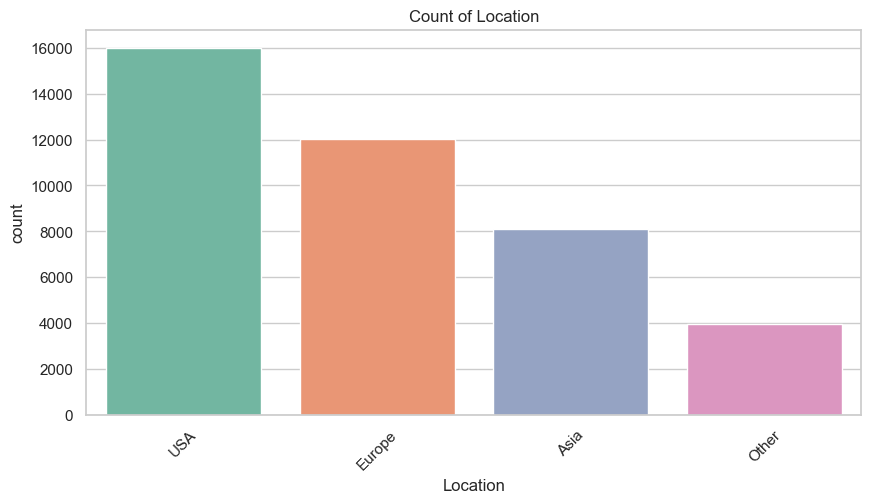

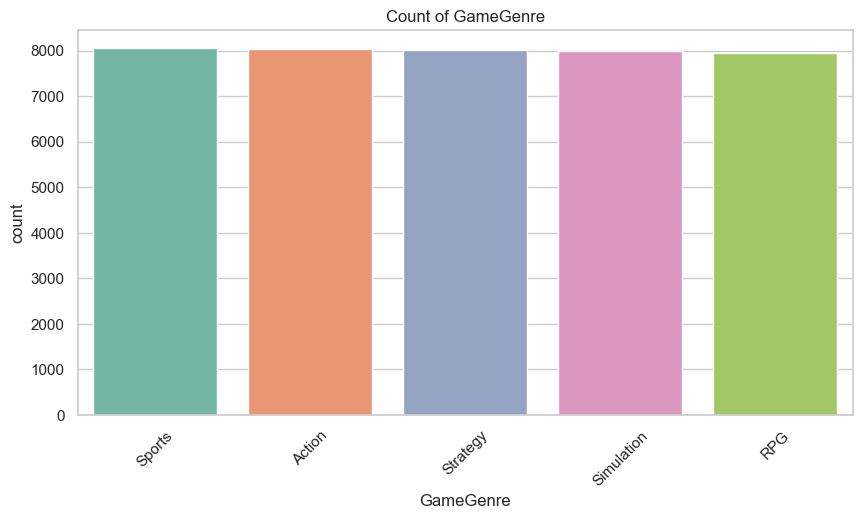

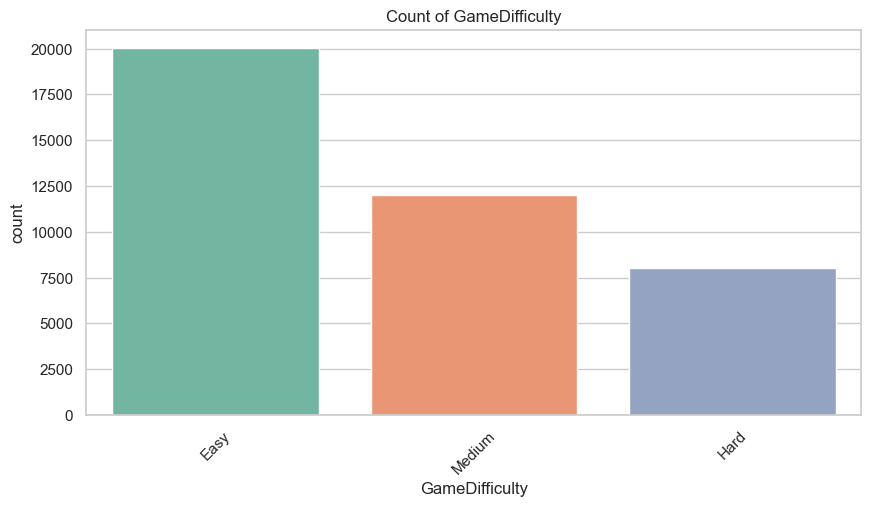

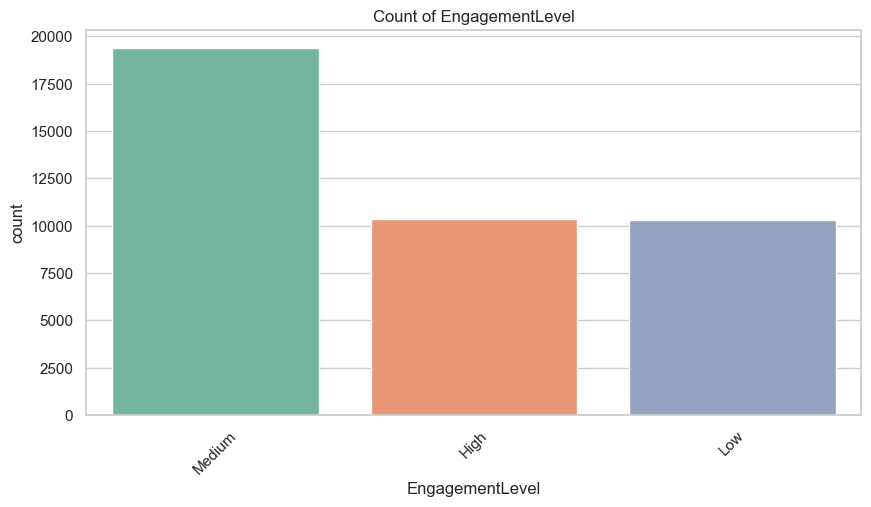

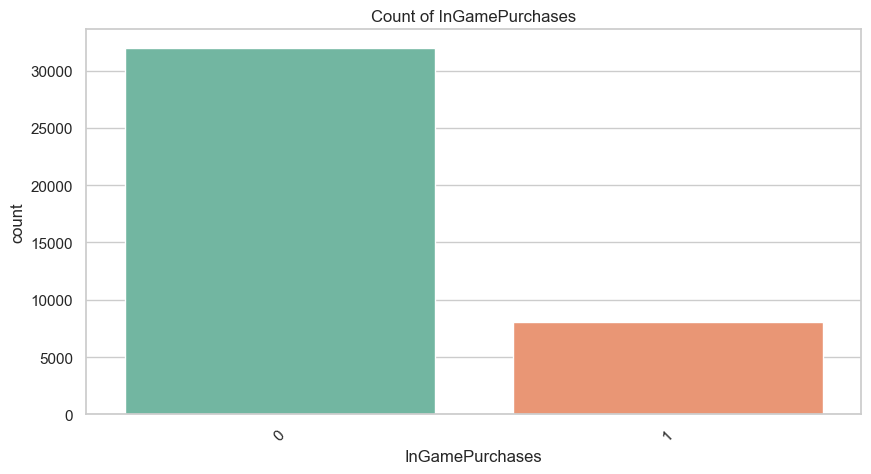

In [11]:
 # categorical features analysis ...
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
categorical_features.append('InGamePurchases')  # include the target variable
for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45) # 
    plt.show()

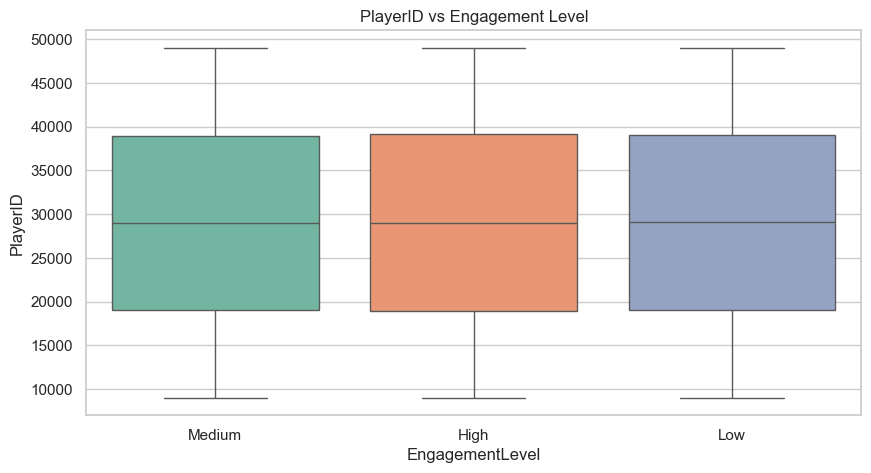

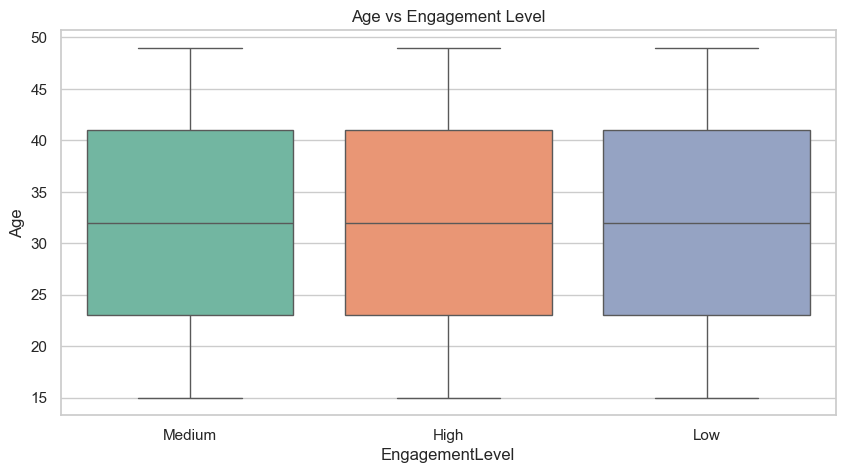

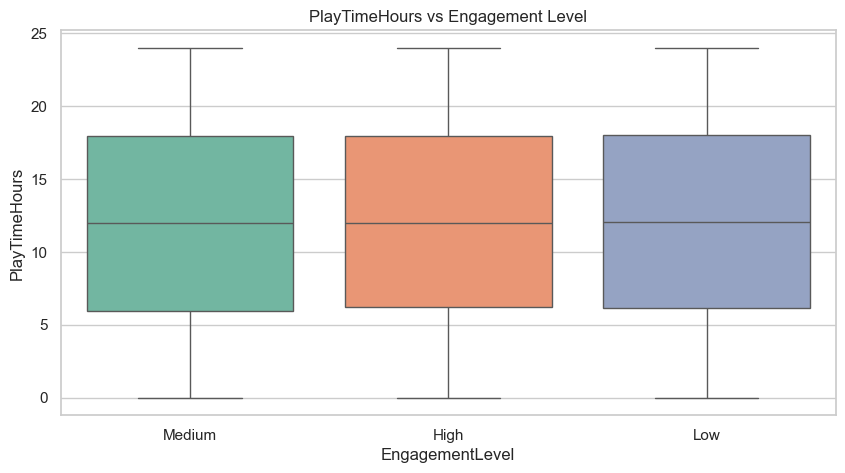

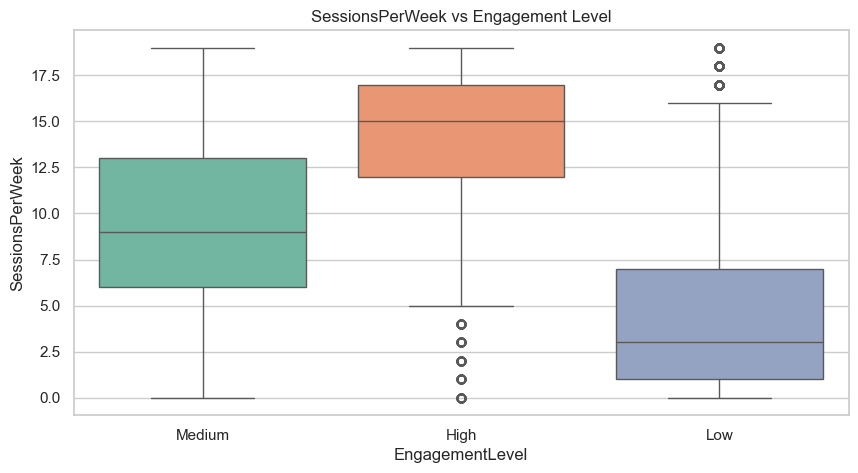

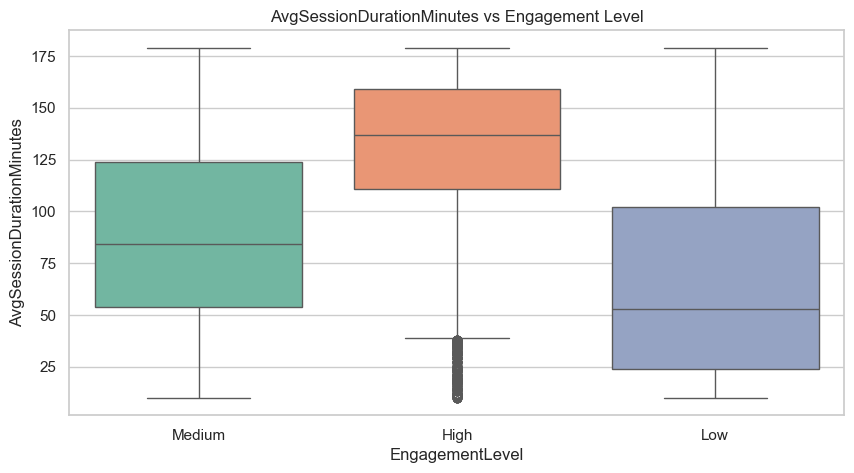

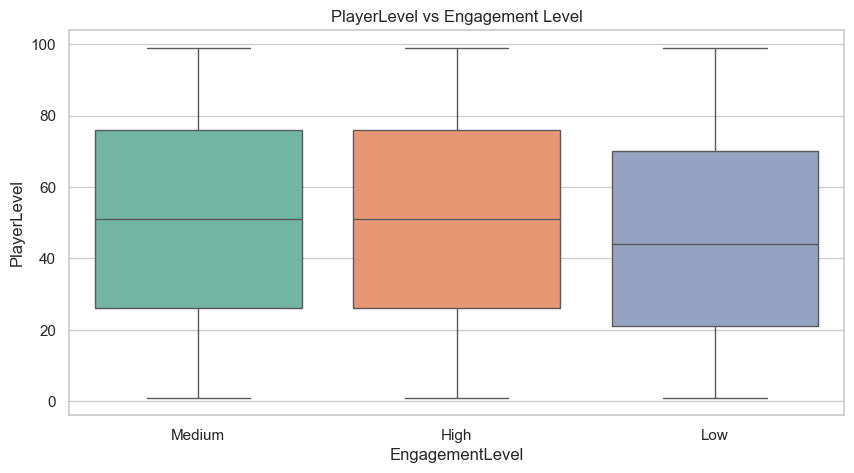

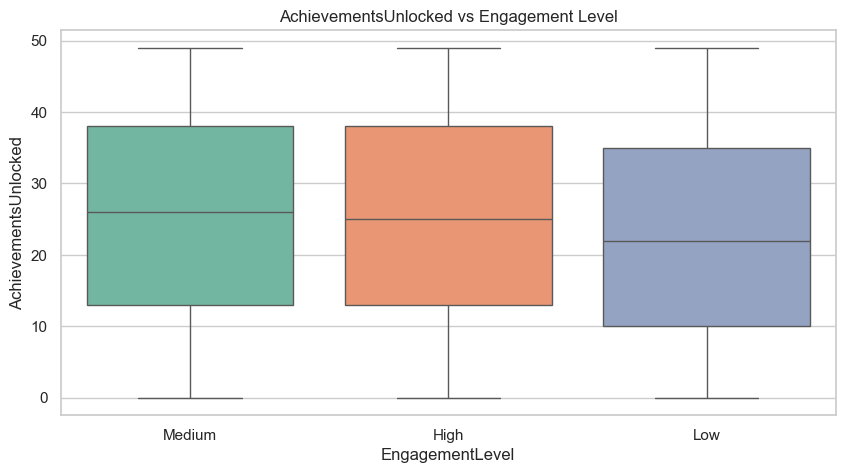

In [12]:
# Bivariate analysis (feature vs engagement level) ...
for col in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='EngagementLevel', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Engagement Level')
    plt.show()

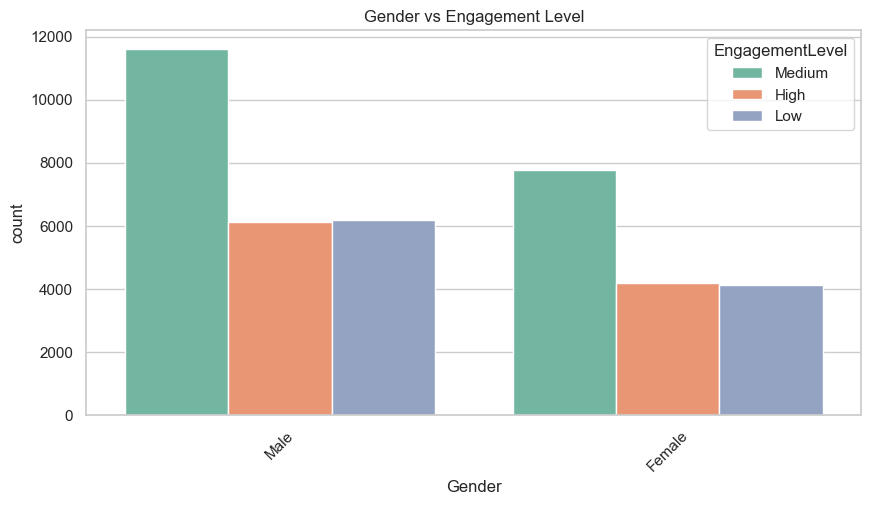

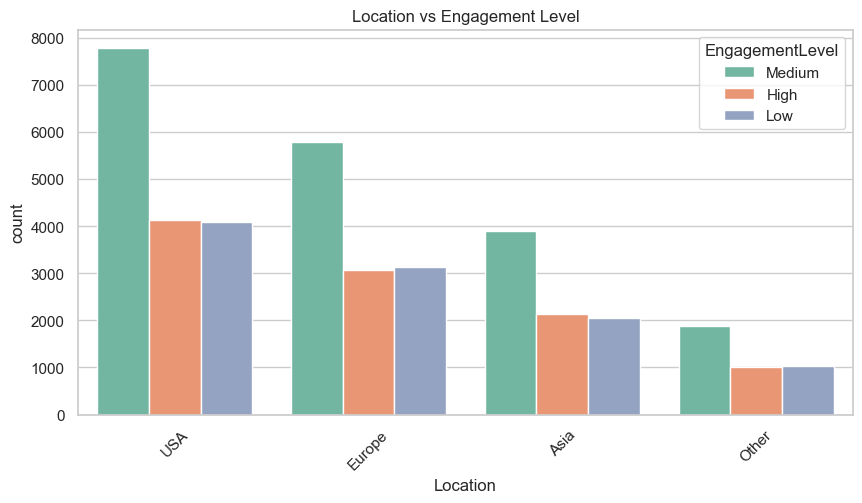

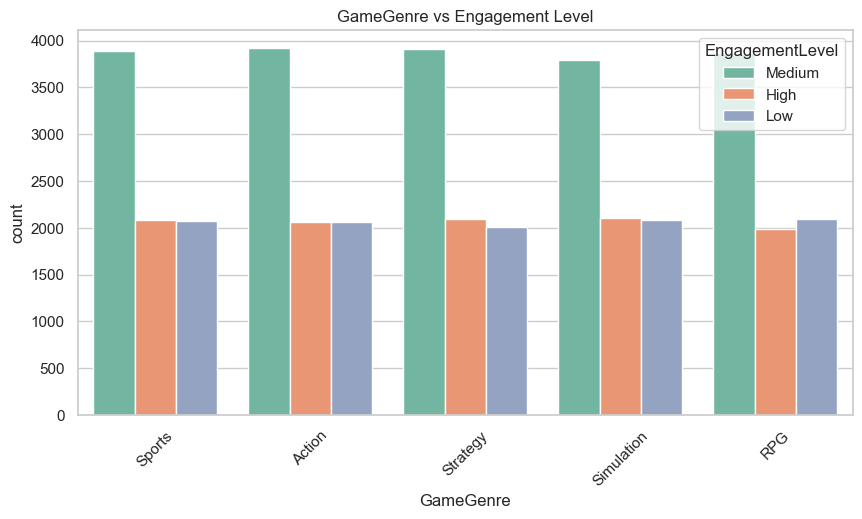

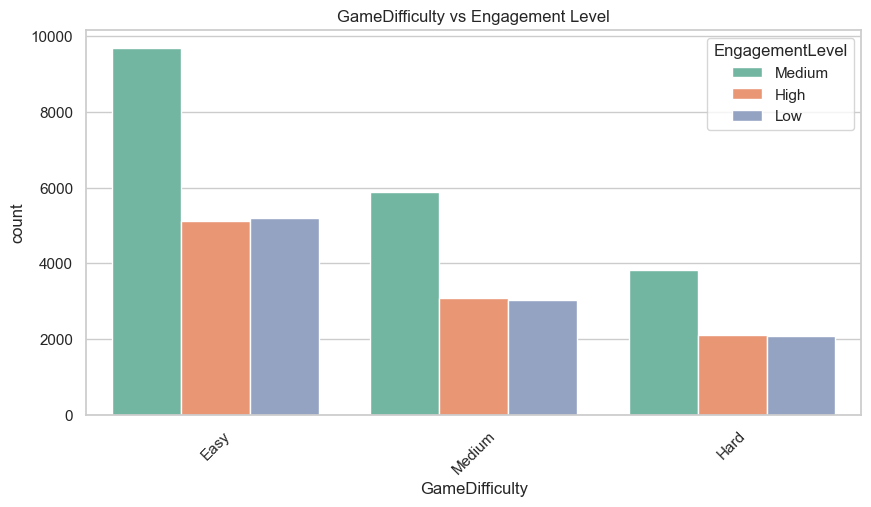

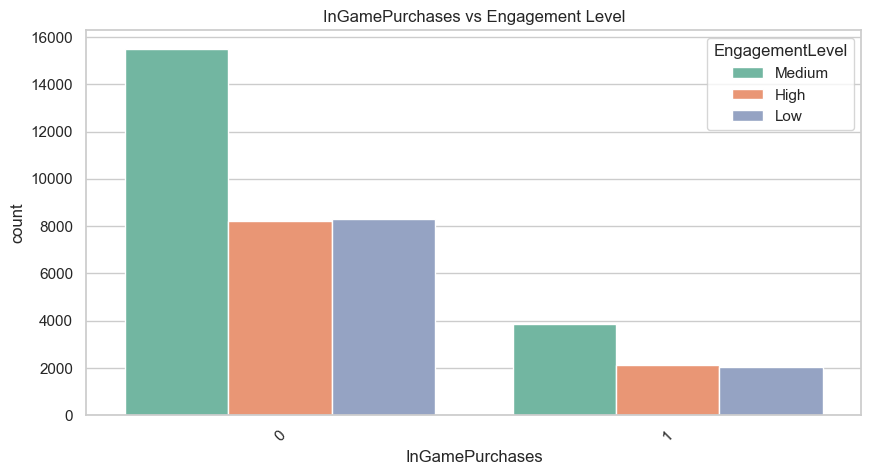

In [13]:
# Categorical features vs engagement level ...
# we use count plots to visualize the relationship between categorical features and engagement level
cat_cols_no_target= ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'InGamePurchases']
for col in cat_cols_no_target:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='EngagementLevel', data=df, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'{col} vs Engagement Level')
    plt.xticks(rotation=45)
    plt.show()

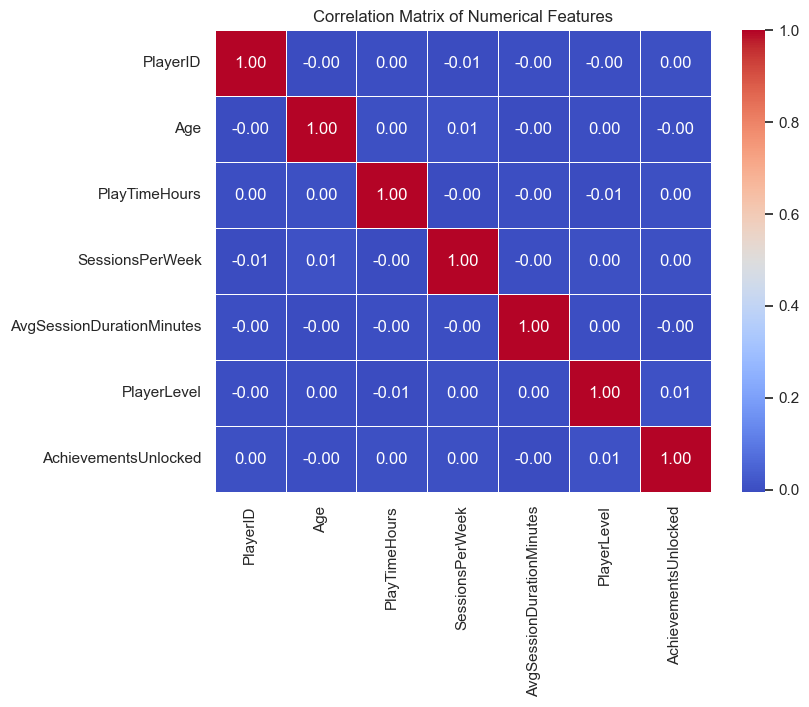

In [14]:
# Multivariate analysis (correlation matrix) ...
# we use a heatmap to visualize the correlation between numerical features
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##### Feature Engineering and Preprocessing
* Droping Player id column as it is not useful for prediction
* Separating the features and target variable
* Split the dataset into training and testing sets
* One-hot encoding for categorical features


In [15]:
# dropping the playerID column as it is not a useful feature for prediction
df_model = df.drop(columns=['PlayerID'])

x= df_model.drop(columns=['EngagementLevel'])
y= df_model['EngagementLevel']

print ('Shape of x: ', x.shape)
print ('Distribution of y: ', y.value_counts())

Shape of x:  (40034, 11)
Distribution of y:  EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


In [16]:
# Splitting the dataset into training and testing sets ...
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ', X_test.shape)
print('Shape of y_train: ', y_train.shape)
print('Shape of y_test: ', y_test.shape)

Shape of X_train:  (32027, 11)
Shape of X_test:  (8007, 11)
Shape of y_train:  (32027,)
Shape of y_test:  (8007,)


In [17]:
# one-hot encoding with get_dummies ...
X_train_enc = pd.get_dummies(X_train, drop_first=False)
X_test_enc = pd.get_dummies(X_test, drop_first=False)

# align columns so that both training and testing sets have the same features
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print('Shape of X_train_enc: ', X_train_enc.shape)
print('Shape of X_test_enc: ', X_test_enc.shape)


Shape of X_train_enc:  (32027, 21)
Shape of X_test_enc:  (8007, 21)


In [18]:
# Train the model using baseline decision tree  ...
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_enc, y_train)
# pre
y_pred_base = dt_base.predict(X_test_enc)
print('Baseline Decision Tree Classifier Accuracy: ', accuracy_score(y_test, y_pred_base))

Baseline Decision Tree Classifier Accuracy:  0.8335206694142625


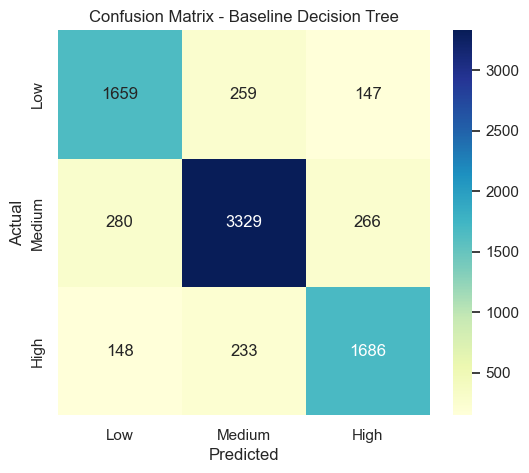

In [19]:
# Confusion matrix...
cm = confusion_matrix(y_test,y_pred_base, labels=['Low','Medium','High'])

plt.figure(figsize = (6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Low','Medium','High'], cmap='YlGnBu', yticklabels = ['Low','Medium','High'])
plt.title('Confusion Matrix - Baseline Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
cm

array([[1659,  259,  147],
       [ 280, 3329,  266],
       [ 148,  233, 1686]])

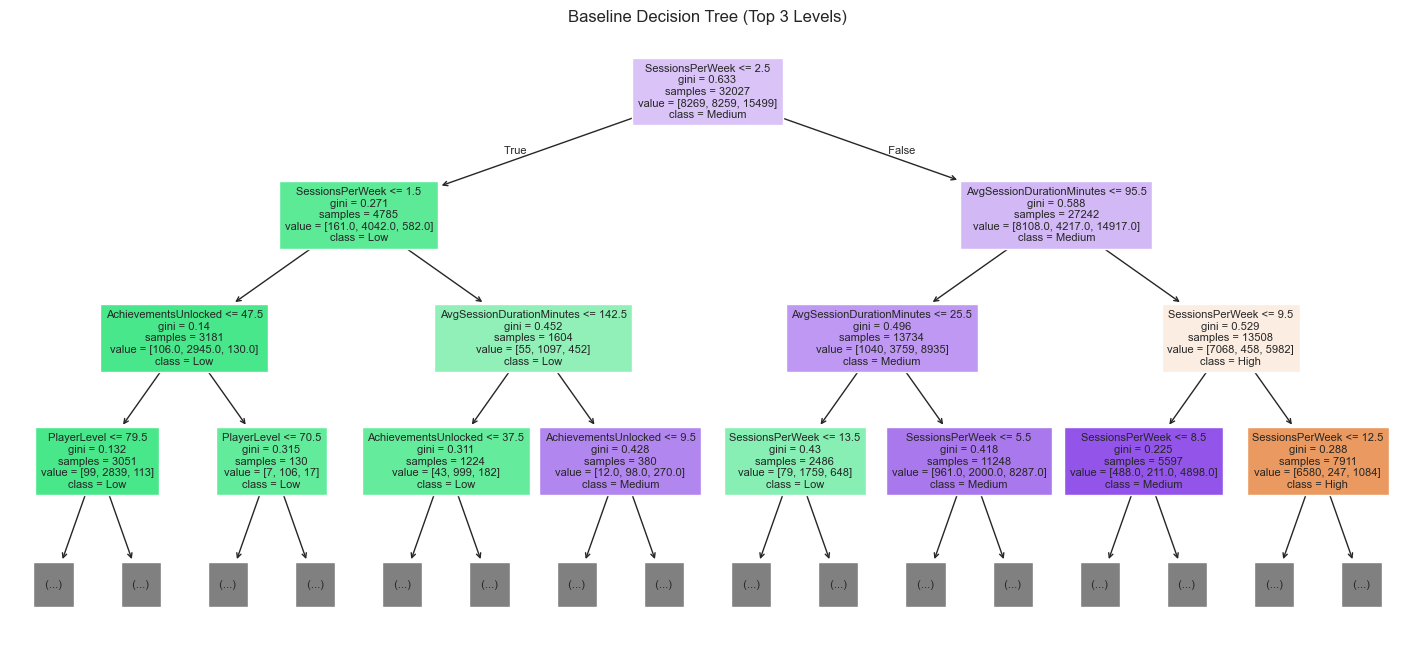

In [21]:
# Decision tree structure not important to write the code in exams and all...
# so need to do this step...
plt.figure(figsize=(18, 8))

plot_tree(

    dt_base,

    # FIX: Add .tolist() here

    feature_names=X_train_enc.columns.tolist(),  

    class_names=dt_base.classes_.tolist(), # Good practice to convert this too

    filled=True,

    max_depth=3,

    fontsize=8

)

plt.title('Baseline Decision Tree (Top 3 Levels)')

plt.show()

In [22]:
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [3,5,8,12,None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,5,10]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs=-1
)

grid.fit(X_train_enc,  y_train)
print('Best Params:' ,grid.best_params_)
print('Best of CV Accuracy:', grid.best_score_)

Best Params: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best of CV Accuracy: 0.9054548489986578


In [23]:
#evaluate Tuned Model on test set 

dt_tuned = grid.best_estimator_
y_pred_tuned = dt_tuned.predict(X_test_enc)

print('Accuracy Tuned:', accuracy_score(y_test, y_pred_tuned))
print('\n Classification report tuned:\n')
print(classification_report(y_test, y_pred_tuned))

Accuracy Tuned: 0.9023354564755839

 Classification report tuned:

              precision    recall  f1-score   support

        High       0.91      0.88      0.89      2067
         Low       0.89      0.87      0.88      2065
      Medium       0.91      0.93      0.92      3875

    accuracy                           0.90      8007
   macro avg       0.90      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007



In [24]:
#Create a validation split from training data for pruning selection
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train_enc, y_train, test_size=0.2, random_state=42, stratify=y_train )
print('Train_sub:', X_train_sub.shape, '|val:', X_val.shape)

Train_sub: (25621, 21) |val: (6406, 21)


In [25]:
#Get pruning path from the tuned model structure
path = dt_tuned.cost_complexity_pruning_path(X_train_sub, y_train_sub)
ccp_alphas = path.ccp_alphas
print('Number of candidate alphas:', len(ccp_alphas))
print('First 10 alphas:', ccp_alphas[:10])

Number of candidate alphas: 652
First 10 alphas: [0.00000000e+00 0.00000000e+00 6.20374578e-06 1.12239651e-05
 1.78331135e-05 1.78331135e-05 2.45506856e-05 2.72054600e-05
 2.78814511e-05 3.11735750e-05]


In [26]:
#Train trees for a subset of alphas (to keep it fast and readable)
alphas_to_try = np.unique(np.round(ccp_alphas, 6))
val_scores = []
models = []
for alpha in alphas_to_try:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        criterion=dt_tuned.criterion,
        max_depth=dt_tuned.max_depth,
        min_samples_split=dt_tuned.min_samples_split,
        min_samples_leaf=dt_tuned.min_samples_leaf,
    )
    model.fit(X_train_sub, y_train_sub)
    pred_val = model.predict(X_val)
    acc_val = accuracy_score(y_val, pred_val)
    val_scores.append(acc_val)
    models.append(model)

best_idx = int(np.argmax(val_scores))
best_alpha = alphas_to_try[best_idx]

print('Best ccp_alpha:', best_alpha)
print('Best validation accuracy:', val_scores[best_idx])

Best ccp_alpha: 0.000357
Best validation accuracy: 0.9035279425538557


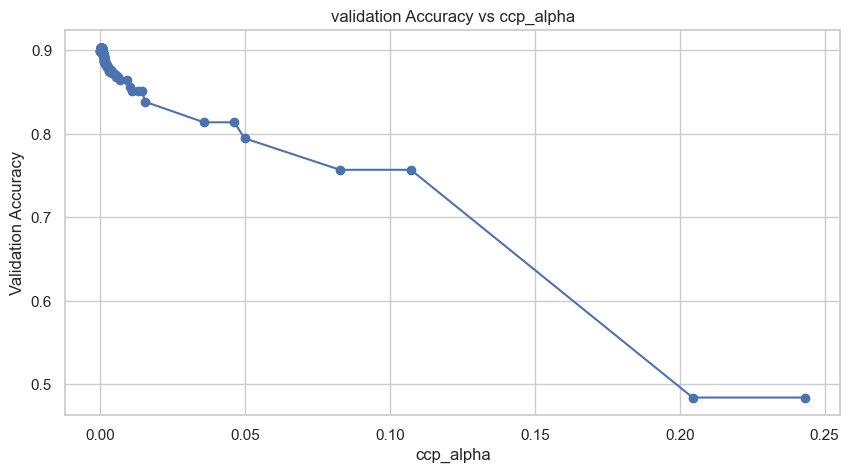

In [27]:
#Plot validation accuracy vs ccp_alpha
plt.figure(figsize=(10, 5))
plt.plot(alphas_to_try, val_scores, marker='o')
plt.title("validation Accuracy vs ccp_alpha")
plt.xlabel('ccp_alpha')
plt.ylabel('Validation Accuracy')
plt.show()

In [28]:
#Train final pruned model on full training data (train set)
dt_pruned = DecisionTreeClassifier(
random_state=42,
ccp_alpha=best_alpha,
criterion=dt_tuned.criterion,
max_depth=dt_tuned.max_depth,
min_samples_split=dt_tuned.min_samples_split,
min_samples_leaf=dt_tuned.min_samples_leaf
)
dt_pruned.fit(X_train_enc, y_train)
y_pred_pruned= dt_pruned.predict(X_test_enc)
print('Accuracy (Pruned):', accuracy_score(y_test, y_pred_pruned))
print('\nClassification Report (Pruned):\n')
print(classification_report(y_test, y_pred_pruned))

Accuracy (Pruned): 0.9023354564755839

Classification Report (Pruned):

              precision    recall  f1-score   support

        High       0.91      0.88      0.90      2067
         Low       0.89      0.87      0.88      2065
      Medium       0.90      0.93      0.92      3875

    accuracy                           0.90      8007
   macro avg       0.90      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007



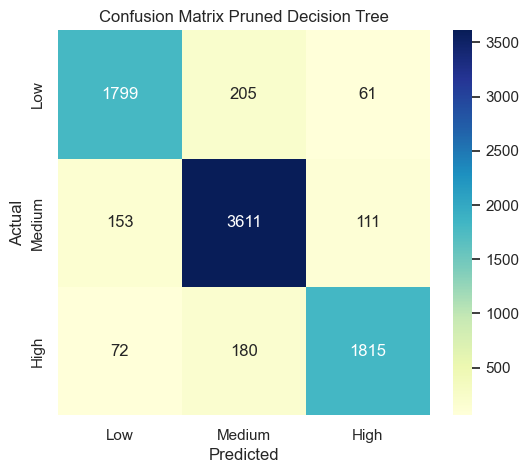

In [29]:
#Confusion matrix (Pruned)
cm_pruned = confusion_matrix(y_test, y_pred_pruned, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pruned, annot=True, fmt='d',cmap='YlGnBu', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix Pruned Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

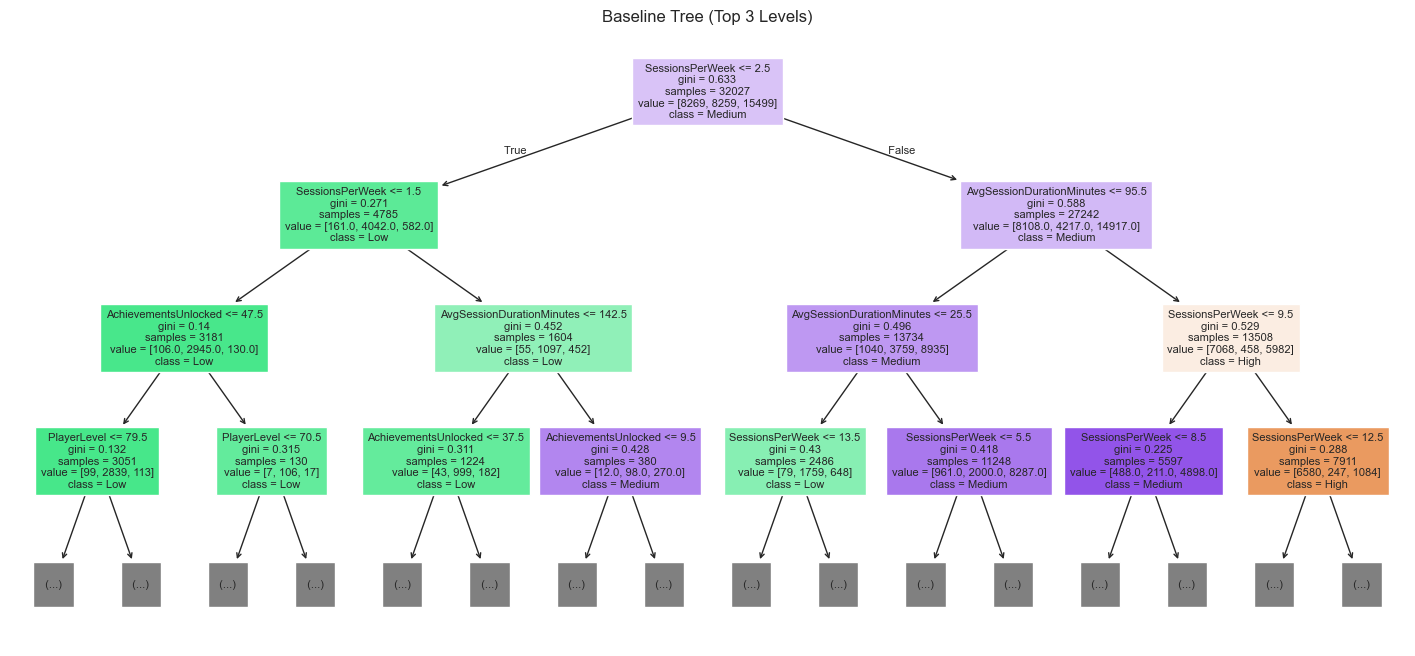

In [30]:
# --- Baseline Tree Visualization ---

plt.figure(figsize=(18, 8))

plot_tree(

    dt_base,

    # FIX: Added .tolist() to convert Index to list

    feature_names=X_train_enc.columns.tolist(),

    # FIX: Added .tolist() to convert Array to list

    class_names=dt_base.classes_.tolist(),

    filled=True,

    max_depth=3,

    fontsize=8

)

plt.title('Baseline Tree (Top 3 Levels)')

plt.show()

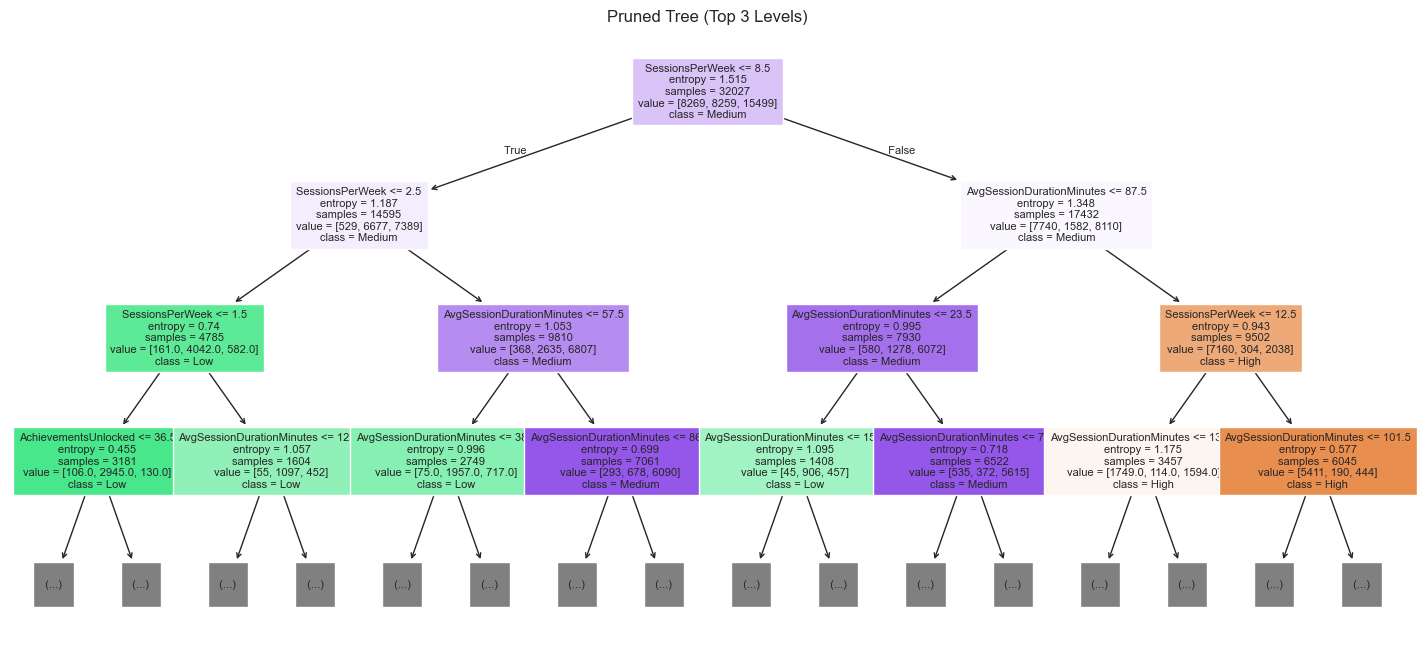

In [31]:
# --- Pruned Tree Visualization ---

plt.figure(figsize=(18, 8))

plot_tree(

    dt_pruned,

    # FIX: Added .tolist() here as well

    feature_names=X_train_enc.columns.tolist(),

    # FIX: Added .tolist() here as well

    class_names=dt_pruned.classes_.tolist(),

    filled=True,

    max_depth=3,

    fontsize=8

)

plt.title('Pruned Tree (Top 3 Levels)')

plt.show()

In [32]:
from sklearn.metrics import f1_score
results = []
# Baseline
results.append({
'Model': 'Baseline Tree',
'Accuracy': accuracy_score(y_test, y_pred_base),
'Macro F1': f1_score(y_test, y_pred_base, average='macro')
})
#Tuned
results.append({
'Model': 'Tuned Tree (Gridsearch)',
'Accuracy': accuracy_score(y_test, y_pred_tuned),
'Macro F1': f1_score(y_test, y_pred_tuned, average='macro')
})
# Pruned
results.append({
'Model': 'Pruned Tree (ccp_alpha)',
'Accuracy': accuracy_score(y_test, y_pred_pruned),
'Macro F1': f1_score(y_test, y_pred_pruned, average='macro')
})

pd.DataFrame(results).sort_values(by=['Macro F1', 'Accuracy'], ascending=False)

,Model,Accuracy,Macro F1
1,Tuned Tree (Gridsearch),0.902335,0.897715
2,Pruned Tree (ccp_alpha),0.902335,0.897626
0,Baseline Tree,0.833521,0.824556


In [ ]:
#SVM ,Knn , Time Series is need to analyze ...